# Análise Final do Case CVM

Este notebook consolida os resultados finais do projeto, com foco em:
- performance do baseline temporal
- drivers mais relevantes do fluxo futuro
- comportamento do target por quantis de features-chave
- diferenças por perfil de fundo
- evidências visuais para o Estudo Padrão e o Dossiê Técnico

In [13]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

BASE_DIR = Path.cwd().resolve().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts"

FUNDS_SCOPE_SUMMARY_PATH = PROCESSED_DIR / "funds_scope_summary.json"
FUNDS_FEATURES_PATH = PROCESSED_DIR / "funds_features.parquet"
FUNDS_FEATURES_SUMMARY_PATH = PROCESSED_DIR / "funds_features_summary.json"
BASELINE_RESULTS_PATH = ARTIFACTS_DIR / "flow_baseline_results.json"
BASELINE_IMPORTANCE_PATH = ARTIFACTS_DIR / "flow_baseline_feature_importance.csv"
BASELINE_PREDICTIONS_PATH = ARTIFACTS_DIR / "flow_baseline_holdout_predictions.parquet"

df_features = pd.read_parquet(FUNDS_FEATURES_PATH)
df_predictions = pd.read_parquet(BASELINE_PREDICTIONS_PATH)
importance_df = pd.read_csv(BASELINE_IMPORTANCE_PATH)

with open(FUNDS_SCOPE_SUMMARY_PATH, "r", encoding="utf-8") as file:
    scope_summary = json.load(file)

with open(FUNDS_FEATURES_SUMMARY_PATH, "r", encoding="utf-8") as file:
    features_summary = json.load(file)

with open(BASELINE_RESULTS_PATH, "r", encoding="utf-8") as file:
    baseline_results = json.load(file)

df_features["DT_COMPTC"] = pd.to_datetime(df_features["DT_COMPTC"])
df_predictions["DT_COMPTC"] = pd.to_datetime(df_predictions["DT_COMPTC"])

df_holdout = df_features.merge(
    df_predictions[["ENTITY_KEY", "DT_COMPTC", "prediction", "baseline_median_prediction"]],
    on=["ENTITY_KEY", "DT_COMPTC"],
    how="inner",
)

target_col = "target_flow_pct_t1_t21_clipped"

## 1. Resumo executivo dos resultados

Esta seção resume a amostra final, o calendário, os splits temporais e as métricas principais do holdout.

In [14]:
resumo = pd.DataFrame([
    {
        "item": "linhas da base de features",
        "valor": features_summary["sample"]["rows"],
    },
    {
        "item": "entidades da base de features",
        "valor": features_summary["sample"]["entities"],
    },
    {
        "item": "início da base de features",
        "valor": features_summary["sample"]["period_start"],
    },
    {
        "item": "fim da base de features",
        "valor": features_summary["sample"]["period_end"],
    },
    {
        "item": "linhas removidas por calendário B3",
        "valor": scope_summary["calendar_quality"]["non_business_rows_removed"],
    },
    {
        "item": "mediana do valid_day_ratio",
        "valor": scope_summary["calendar_quality"]["median_valid_day_ratio"],
    },
    {
        "item": "MAE holdout baseline",
        "valor": baseline_results["metrics"]["test_baseline"]["mae"],
    },
    {
        "item": "MAE holdout modelo",
        "valor": baseline_results["metrics"]["test_model"]["mae"],
    },
    {
        "item": "RMSE holdout baseline",
        "valor": baseline_results["metrics"]["test_baseline"]["rmse"],
    },
    {
        "item": "RMSE holdout modelo",
        "valor": baseline_results["metrics"]["test_model"]["rmse"],
    },
])

resumo

,item,valor
0,linhas da base de features,1185572
1,entidades da base de features,3725
2,início da base de features,2024-10-29
3,fim da base de features,2026-03-11
4,linhas removidas por calendário B3,14689
5,mediana do valid_day_ratio,1.0000
6,MAE holdout baseline,0.0346
7,MAE holdout modelo,0.0375
8,RMSE holdout baseline,0.1015
9,RMSE holdout modelo,0.0986


## 2. Qualidade da amostra e calendário

Aqui o objetivo é deixar visível que a base final respeita o calendário de negociação da B3 e que a cobertura por entidade ficou alta.

In [15]:
calendar_cols = ["valid_day_ratio", "observed_business_days", "expected_business_days"]
df_features[calendar_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
valid_day_ratio,"1,185,572.0000",0.9953,0.0043,0.8871,0.9837,0.9939,0.9959,0.9959,0.9959,1.0000
observed_business_days,"1,185,572.0000",481.0048,36.6286,151.0000,276.0000,418.0000,490.0000,490.0000,490.0000,490.0000
expected_business_days,"1,185,572.0000",483.2521,36.5746,152.0000,277.0000,420.0000,492.0000,492.0000,492.0000,492.0000


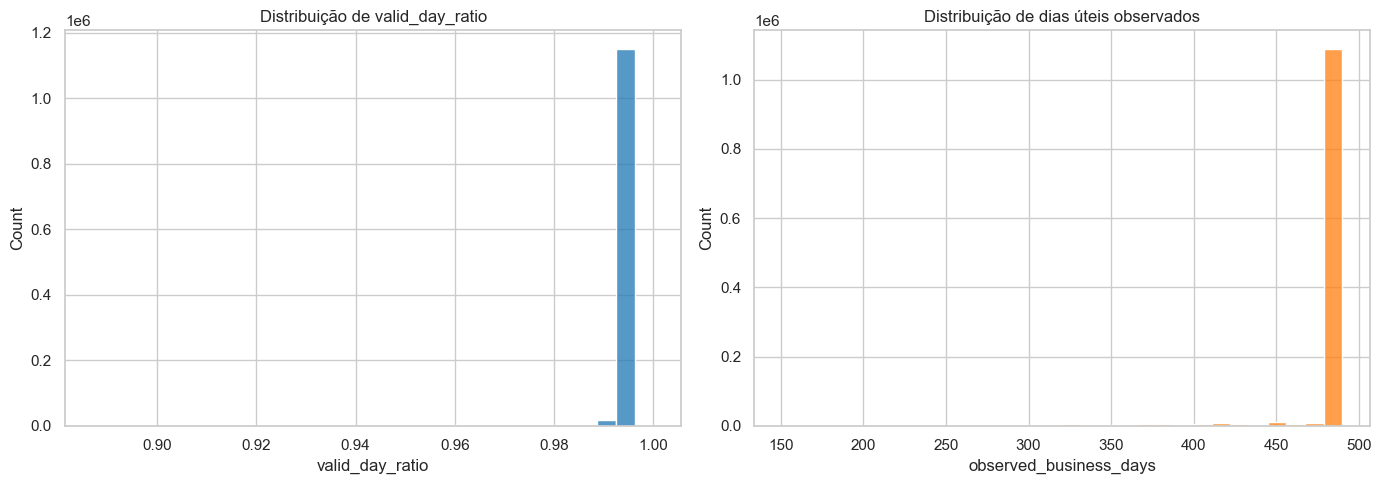

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_features["valid_day_ratio"], bins=30, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribuição de valid_day_ratio")
axes[0].set_xlabel("valid_day_ratio")

sns.histplot(df_features["observed_business_days"], bins=30, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Distribuição de dias úteis observados")
axes[1].set_xlabel("observed_business_days")

plt.tight_layout()

## 3. Distribuição final do target

O target é assimétrico e concentrado em zero. Esta seção ajuda a justificar a escolha de métricas robustas e o clipping para regressão.

In [17]:
df_features[target_col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("target")

,target
count,"1,185,572.0000"
mean,-0.0098
std,0.0986
min,-1.0000
1%,-0.3217
5%,-0.1120
50%,0.0000
95%,0.0634
99%,0.2881
max,1.0000


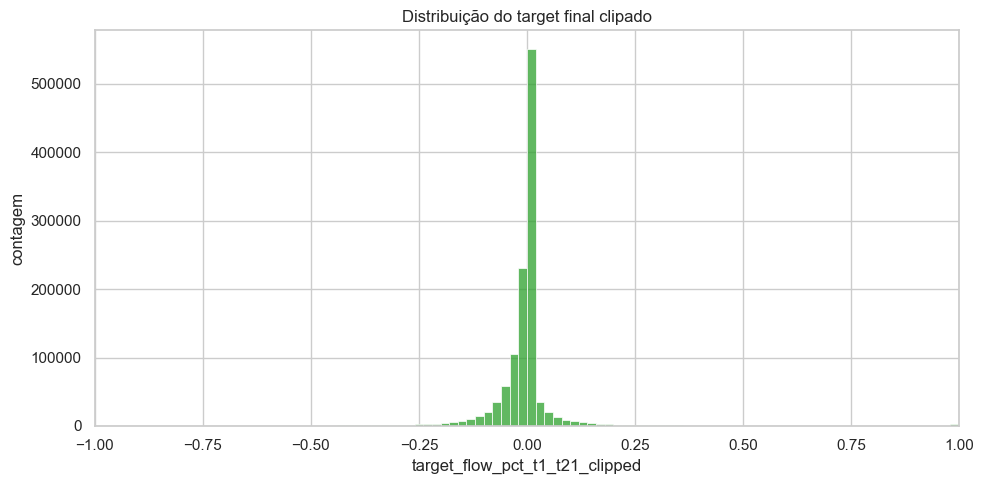

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df_features[target_col], bins=100, color="#2ca02c")
plt.title("Distribuição do target final clipado")
plt.xlabel(target_col)
plt.ylabel("contagem")
plt.xlim(-1, 1)
plt.tight_layout()

## 4. Baseline vs modelo no holdout

Comparação direta entre baseline ingênuo e modelo final no conjunto de teste temporal.

In [19]:
metricas = pd.DataFrame(
    {
        "baseline": baseline_results["metrics"]["test_baseline"],
        "modelo": baseline_results["metrics"]["test_model"],
    }
).T

metricas

,mae,rmse
baseline,0.0346,0.1015
modelo,0.0375,0.0986


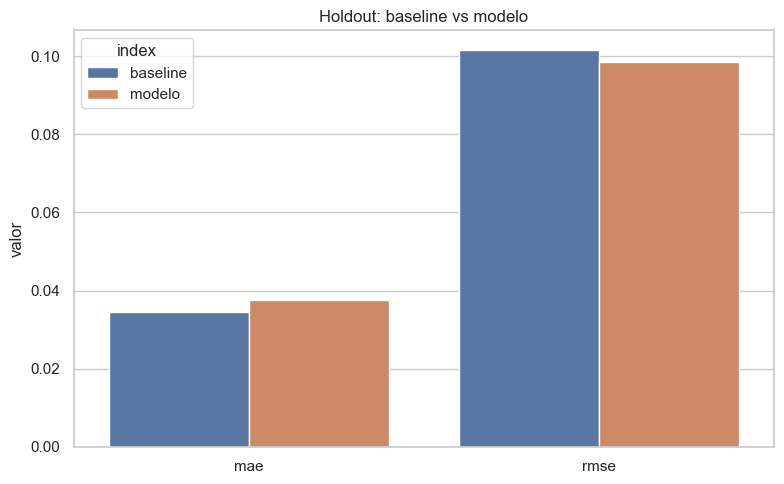

In [20]:
metrics_plot = metricas.reset_index().melt(id_vars="index", value_vars=["mae", "rmse"], var_name="metrica", value_name="valor")

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_plot, x="metrica", y="valor", hue="index")
plt.title("Holdout: baseline vs modelo")
plt.xlabel("")
plt.ylabel("valor")
plt.tight_layout()

## 5. Importância das features

Este é um dos blocos mais úteis para o dossiê técnico. Aqui aparecem os sinais com maior contribuição incremental no holdout.

In [21]:
importance_df.head(15)

,feature,importance_mean,importance_std
0,flow_pct_63d_sum,0.0021,0.0000
1,ex_flow_return_5d_mean,0.0005,0.0000
2,ret_5d,0.0004,0.0000
3,vol_63d,0.0003,0.0000
4,flow_pct_5d_sum,0.0003,0.0000
5,log_nr_cotst_lag1,0.0003,0.0000
6,log_pl_lag1,0.0002,0.0000
7,ex_flow_return_21d_mean,0.0002,0.0000
8,anbima_bucket,0.0002,0.0000
9,flow_pct_21d_sum,0.0002,0.0000


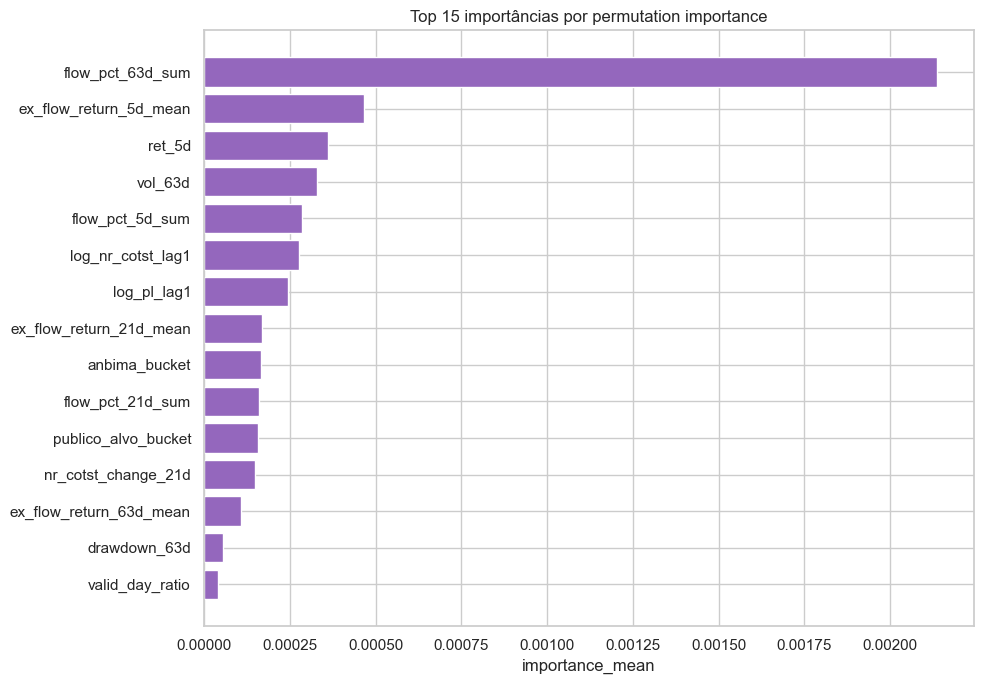

In [22]:
top_imp = importance_df.head(15).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_imp["feature"], top_imp["importance_mean"], color="#9467bd")
plt.title("Top 15 importâncias por permutation importance")
plt.xlabel("importance_mean")
plt.tight_layout()

## 5A. Gráfico executivo para o Estudo Padrão: principais drivers

Esta versão reduzida do gráfico de importâncias foi pensada para exportação direta para o PDF executivo.

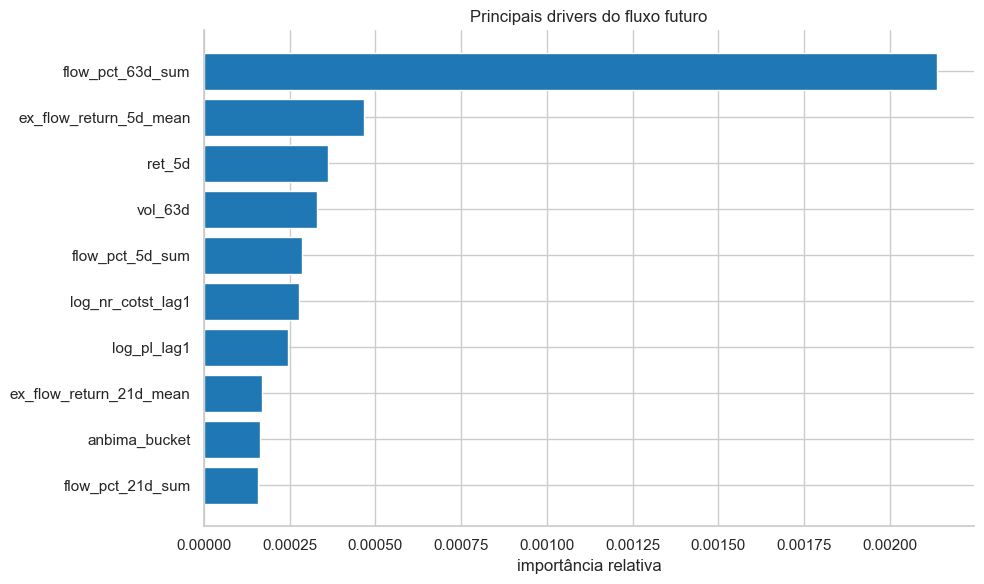

In [23]:
top_imp_exec = importance_df.head(10).sort_values("importance_mean", ascending=True).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_imp_exec["feature"], top_imp_exec["importance_mean"], color="#1f77b4")
plt.title("Principais drivers do fluxo futuro")
plt.xlabel("importância relativa")
plt.ylabel("")
sns.despine()
plt.tight_layout()

## 6. Quantis de features-chave vs fluxo futuro

Aqui a ideia é transformar os drivers do modelo em leitura de negócio: como o fluxo futuro se comporta quando a feature está em quantis mais baixos ou mais altos.

In [24]:
def quantile_summary(frame, column, target=target_col, q=10):
    temp = frame[[column, target]].dropna().copy()
    temp["quantil"] = pd.qcut(temp[column], q=q, duplicates="drop")
    summary = temp.groupby("quantil", observed=False).agg(
        media_target=(target, "mean"),
        mediana_target=(target, "median"),
        contagem=(target, "size"),
    ).reset_index()
    summary["quantil_str"] = summary["quantil"].astype(str)
    return summary


key_features = [
    "flow_pct_63d_sum",
    "ret_5d",
    "vol_63d",
    "log_pl_lag1",
]

quantile_tables = {feature: quantile_summary(df_features, feature) for feature in key_features}
quantile_tables["flow_pct_63d_sum"]

,quantil,media_target,mediana_target,contagem,quantil_str
0,"(-3.521, -0.185]",-0.0435,-0.0193,118560,"(-3.521, -0.185]"
1,"(-0.185, -0.105]",-0.0342,-0.0223,118555,"(-0.185, -0.105]"
2,"(-0.105, -0.0584]",-0.0249,-0.0150,118557,"(-0.105, -0.0584]"
3,"(-0.0584, -0.0264]",-0.0182,-0.0075,118559,"(-0.0584, -0.0264]"
4,"(-0.0264, -0.00252]",-0.0108,-0.0018,118556,"(-0.0264, -0.00252]"
5,"(-0.00252, 0.0]",-0.0023,0.0000,321164,"(-0.00252, 0.0]"
6,"(0.0, 0.00495]",-0.0010,0.0000,34507,"(0.0, 0.00495]"
7,"(0.00495, 0.0726]",0.0046,0.0000,118567,"(0.00495, 0.0726]"
8,"(0.0726, 343.606]",0.0359,0.0002,118547,"(0.0726, 343.606]"


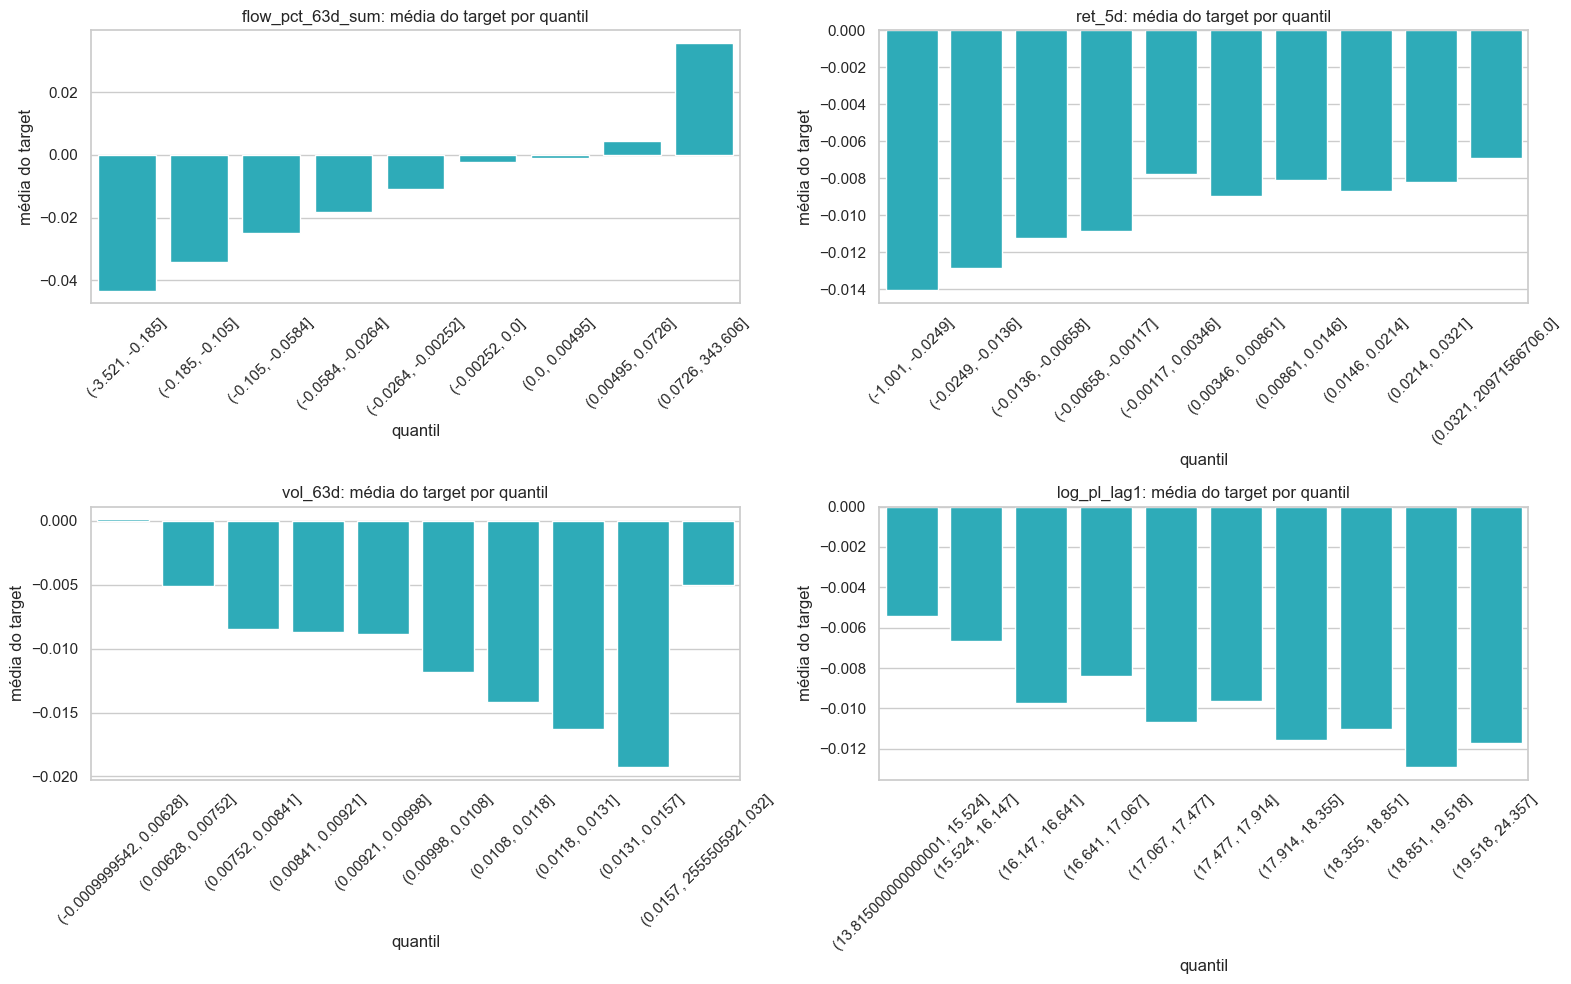

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, key_features):
    summary = quantile_tables[feature]
    sns.barplot(data=summary, x="quantil_str", y="media_target", ax=ax, color="#17becf")
    ax.set_title(f"{feature}: média do target por quantil")
    ax.set_xlabel("quantil")
    ax.set_ylabel("média do target")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

## 6A. Gráfico executivo para o Estudo Padrão: fluxo recente e captação futura

Esta versão isolada do gráfico por quantis foi pensada para ilustrar a relação entre fluxo recente e fluxo futuro no estudo executivo.

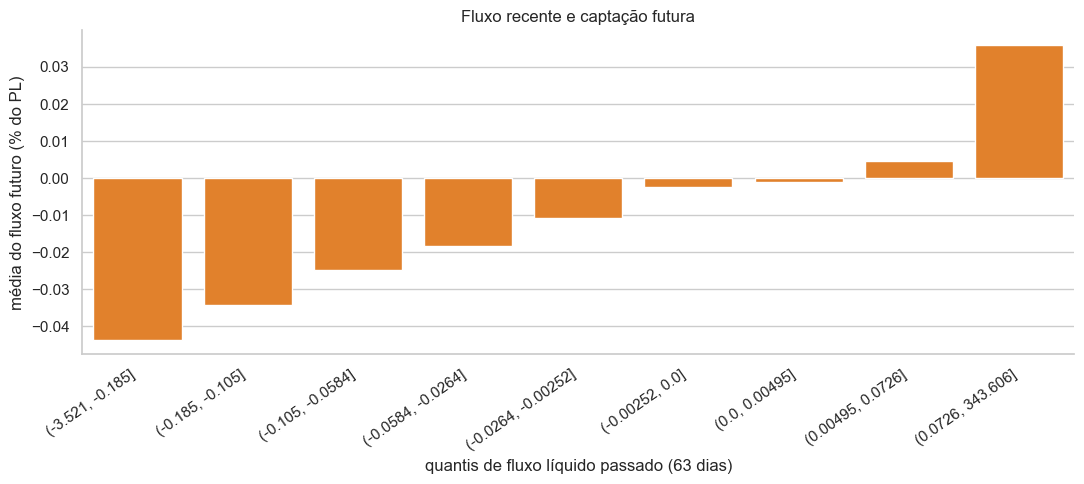

In [26]:
flow_exec = quantile_summary(df_features, "flow_pct_63d_sum").copy()

plt.figure(figsize=(11, 5))
sns.barplot(data=flow_exec, x="quantil_str", y="media_target", color="#ff7f0e")
plt.title("Fluxo recente e captação futura")
plt.xlabel("quantis de fluxo líquido passado (63 dias)")
plt.ylabel("média do fluxo futuro (% do PL)")
plt.xticks(rotation=35, ha="right")
sns.despine()
plt.tight_layout()

## 7. Análise por perfil de fundo

Esta seção mostra se há diferenças sistemáticas de fluxo futuro entre buckets de produto e perfil de investidor.

In [27]:
for col in ["publico_alvo_bucket", "anbima_bucket", "exclusivo_flag"]:
    display(
        df_features.groupby(col, observed=False)[target_col]
        .agg(["count", "mean", "median"])
        .sort_values("count", ascending=False)
        .head(15)
    )

,count,mean,median
publico_alvo_bucket,,,
Profissional,484962,-0.0056,0.0000
Qualificado,360341,-0.0137,-0.0008
Público Geral,329775,-0.0121,-0.0072
Nao Informado,10494,0.0084,0.0000


,count,mean,median
anbima_bucket,,,
Ações Livre,582207,-0.0122,0.0000
Ações Invest. no Exterior,319965,-0.0037,0.0000
Previdência Ações Ativo,88017,-0.0160,-0.0052
Ações Índice Ativo,48484,-0.0178,-0.0005
Fechados de Ações,39418,0.0013,0.0000
Outras,36463,-0.0029,-0.0069
Ações Valor/Crescimento,31420,-0.0259,-0.0093
Ações Indexados,22094,-0.0054,-0.0017
Ações Dividendos,17504,-0.0000,0.0000


,count,mean,median
exclusivo_flag,,,
N,862413,-0.0112,-0.0006
S,313347,-0.0064,0.0000
Nao Informado,9812,0.0095,0.0000


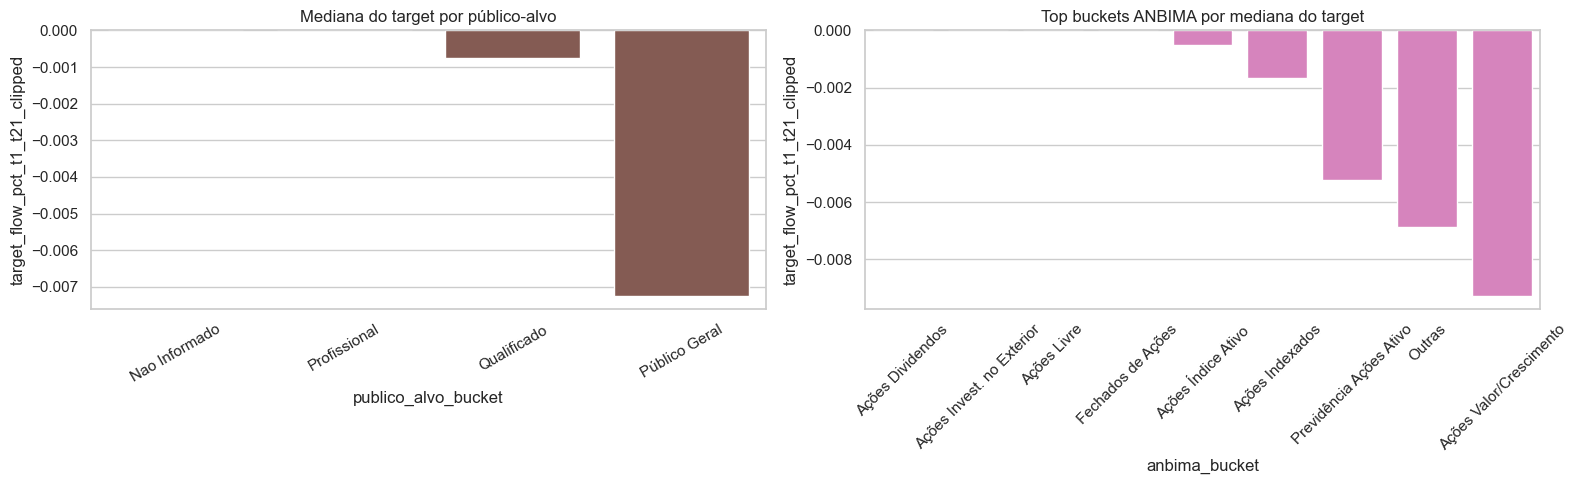

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

publico_plot = (
    df_features.groupby("publico_alvo_bucket", observed=False)[target_col]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=publico_plot, x="publico_alvo_bucket", y=target_col, ax=axes[0], color="#8c564b")
axes[0].set_title("Mediana do target por público-alvo")
axes[0].tick_params(axis="x", rotation=30)

anbima_plot = (
    df_features.groupby("anbima_bucket", observed=False)[target_col]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(data=anbima_plot, x="anbima_bucket", y=target_col, ax=axes[1], color="#e377c2")
axes[1].set_title("Top buckets ANBIMA por mediana do target")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

## 8. Erro do modelo e caudas do target

Bloco útil para interpretar o comportamento do baseline nas observações mais difíceis.

In [29]:
df_holdout["abs_error_model"] = (df_holdout[target_col] - df_holdout["prediction"]).abs()
df_holdout["abs_error_baseline"] = (df_holdout[target_col] - df_holdout["baseline_median_prediction"]).abs()
df_holdout[["abs_error_model", "abs_error_baseline"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
abs_error_model,"229,407.0000",0.0375,0.0912,0.0000,0.0122,0.0817,0.1475,0.4805,1.0748
abs_error_baseline,"229,407.0000",0.0346,0.0954,0.0000,0.0035,0.0853,0.1593,0.5110,1.0000


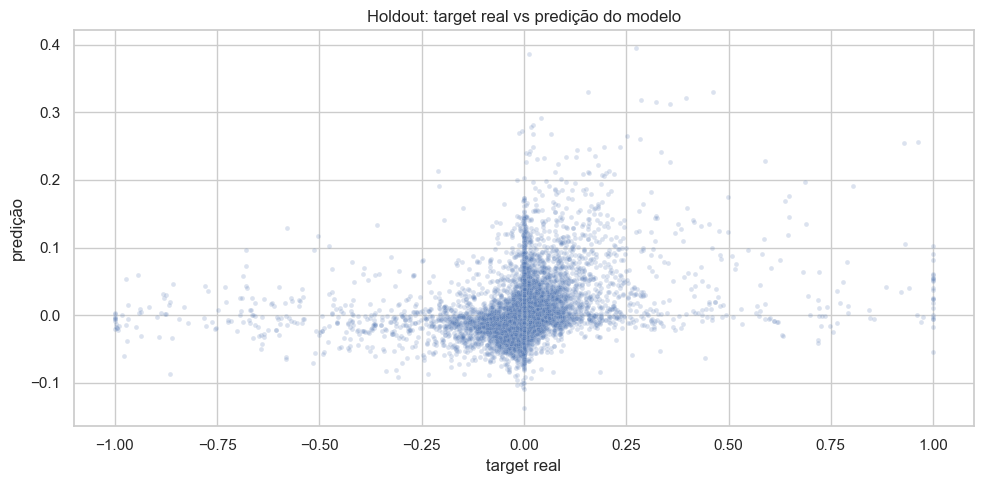

In [30]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_holdout.sample(min(len(df_holdout), 20000), random_state=42),
    x=target_col,
    y="prediction",
    alpha=0.2,
    s=12,
)
plt.title("Holdout: target real vs predição do modelo")
plt.xlabel("target real")
plt.ylabel("predição")
plt.tight_layout()

## 9. Gráficos candidatos para o PDF final

Sugestão prática para o Estudo Padrão:
- comparação baseline vs modelo no holdout
- top 10 importâncias
- quantis de `flow_pct_63d_sum` vs target
- quantis de `vol_63d` vs target
- cobertura por `valid_day_ratio`

Sugestão prática para o Dossiê Técnico:
- distribuição final do target
- resumo do calendário B3 e `valid_day_ratio`
- tabela completa de walk-forward
- análise por público-alvo e bucket ANBIMA

## 10. Conclusões finais

Resumo esperado desta etapa:
- o problema continua difícil, com target muito concentrado em zero
- o modelo melhora RMSE e parece capturar melhor os casos de fluxo mais intenso
- fluxo passado, retorno ex-flow, volatilidade e tamanho são os drivers mais importantes
- a base final ficou bem coberta em termos de calendário B3 e `% de dias válidos`
- o notebook gera o material visual mais útil para os PDFs e para o vídeo final